In [1]:
import torch

In [2]:
import matplotlib.pyplot as plt


def show_heatmaps(
    matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap="Reds"
):
    """Show heatmaps of matrices."""

    num_rows, num_cols, _, _ = matrices.shape

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):

            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)

            if titles:
                ax.set_title(titles[j])

    fig.supxlabel(xlabel)
    fig.supylabel(ylabel)

    fig.colorbar(pcm, ax=axes, shrink=0.6)

    plt.show()

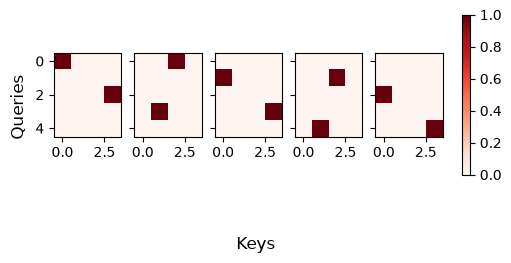

In [3]:
attention_weights = torch.eye(10).reshape((1, 5, 5, 4))
show_heatmaps(attention_weights, xlabel="Keys", ylabel="Queries", figsize=(5, 3))

## Masked Softmax


In [4]:
import torch


def masked_softmax(X, valid_lens=None):
    """Perform softmax while masking out invalid positions.

    Args:
        X: Tensor of shape (batch_size, num_queries, num_kv)
           or (batch_size, num_kv)
        valid_lens: Tensor of shape (batch_size,) or
                    (batch_size, num_queries)

    Returns:
        Tensor with the same shape as X.
    """

    def _sequence_mask(X, valid_lens, value=-1e6):
        max_len = X.shape[-1]
        mask = torch.arange(max_len, device=X.device)[None, :] < valid_lens[:, None]
        X[~mask] = value
        return X

    shape = X.shape

    if valid_lens is None:
        return torch.softmax(X, dim=1)
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)

    X = X.reshape(-1, shape[-1])
    X = _sequence_mask(X, valid_lens)

    return torch.softmax(X.reshape(shape), dim=-1)


masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.2770, 0.4932, 0.2299, 0.0000]],

        [[0.5569, 0.4431, 0.0000, 0.0000],
         [0.2951, 0.2798, 0.2000, 0.2251]]])

## Dot Product Attention


In [5]:
import math
from torch import nn


class DotProductAttention(nn.Module):
    def __init__(self, dropout) -> None:
        super().__init__()

        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # Shape of queries: (batch_size, no. of queries, d)
        # Shape of keys: (batch_size, no. of key-value pairs, d)
        # Shape of values: (batch_size, no. of key-value pairs, value dimension)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = self.masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

    def masked_softmax(self, X, valid_lens=None):
        """Perform softmax while masking out invalid positions.

        Args:
            X: Tensor of shape (batch_size, num_queries, num_kv)
            or (batch_size, num_kv)
            valid_lens: Tensor of shape (batch_size,) or
                        (batch_size, num_queries)

        Returns:
            Tensor with the same shape as X.
        """

        def _sequence_mask(X, valid_lens, value=-1e6):
            max_len = X.shape[-1]
            mask = torch.arange(max_len, device=X.device)[None, :] < valid_lens[:, None]
            X[~mask] = value
            return X

        shape = X.shape

        if valid_lens is None:
            return torch.softmax(X, dim=1)
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = X.reshape(-1, shape[-1])
        X = _sequence_mask(X, valid_lens)

        return torch.softmax(X.reshape(shape), dim=-1)

In [6]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 0.4308, -0.3762,  0.0627,  0.8259]],

        [[-0.5108, -0.3008, -0.2063, -1.0035]]])

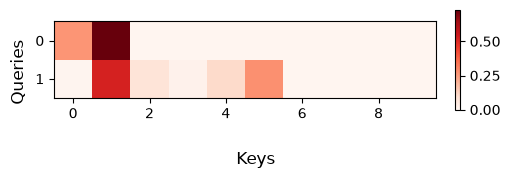

In [7]:
show_heatmaps(
    attention.attention_weights.reshape((1, 1, 2, 10)),
    xlabel="Keys",
    ylabel="Queries",
    figsize=(5, 2),
)

In [8]:
attention.attention_weights

tensor([[[0.2682, 0.7318, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.0042, 0.5256, 0.0718, 0.0151, 0.1058, 0.2777, 0.0000, 0.0000,
          0.0000, 0.0000]]])

## Additive Attention

$$
a(\mathbf{q}, \mathbf{k}) =
\mathbf{w}_v^\top
\tanh\left(
\mathbf{W}_q\mathbf{q}
+
\mathbf{W}_k\mathbf{k}
\right)
\in \mathbb{R}
$$


## Multihead Attention


In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, hiddens, dropout) -> None:
        super().__init__()

        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.Wq = nn.LazyLinear(hiddens)
        self.Wk = nn.LazyLinear(hiddens)
        self.Wv = nn.LazyLinear(hiddens)
        self.Wo = nn.LazyLinear(hiddens)

    def forward(self, queries, keys, values, valid_lens):
        q = self.transpose_qkv(self.Wq(queries))
        k = self.transpose_qkv(self.Wk(keys))
        v = self.transpose_qkv(self.Wv(values))

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, self.num_heads, dim=0)

        output = self.attention(q, k, v, valid_lens)
        output_concat = self.transpose_output(output)
        return self.Wo(output_concat)

    def transpose_qkv(self, x):
        # Initial shape : (batch size, no. of queries or kv, hidden)
        # Converted shape : (batch size, no.of queries, heads, hidden/heads)
        x = x.reshape(x.shape[0], x.shape[1], self.num_heads, -1)
        # Switch dimensions (batch size, heads, no. of queries, hidden/heads)
        x = x.permute(0, 2, 1, 3)
        # make the dimesion (batch size * heads, no. of queries hidden/heads)
        # to easily feed to torch.bmm which expects the tensor of shape (batch, m1, m2)
        return x.reshape(-1, x.shape[2], x.shape[3])

    def transpose_output(self, x):
        """Reverse the operation of transpose_qkv"""
        x = x.reshape(-1, self.num_heads, x.shape[1], x.shape[2])
        x = x.permute(0, 2, 1, 3)
        return x.reshape(x.shape[0], x.shape[1], -1)

In [10]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_heads, num_hiddens, 0.5)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))

attention.eval()
attention(X, Y, Y, valid_lens)

tensor([[[ 0.4459,  0.0642,  0.0620, -0.1751,  0.1158,  0.0044,  0.2640,
          -0.3928, -0.0467,  0.1996,  0.3316,  0.5596, -0.1692, -0.4385,
          -0.2255, -0.6425,  0.3012, -0.2341, -0.0850,  0.1825,  0.2637,
           0.1861,  0.4575, -0.2334,  0.3510, -0.2004, -0.2101, -0.4603,
           0.2071,  0.0147, -0.1259,  0.0884,  0.2310,  0.3979, -0.2459,
           0.1660,  0.1359, -0.4524, -0.0654,  0.1072, -0.1811,  0.1965,
           0.1842,  0.0917,  0.1182, -0.0787, -0.0195,  0.3615, -0.0700,
          -0.3473,  0.3772,  0.2810, -0.5926,  0.0414, -0.5358, -0.0969,
          -0.5059,  0.4958,  0.3992,  0.5344,  0.7612,  0.0114,  0.3668,
          -0.2591, -0.3707, -0.0686, -0.3220,  0.0802,  0.2346,  0.7023,
           0.0082, -0.3850, -0.0762, -0.3777, -0.4482, -0.0820, -0.4076,
           0.1242, -0.1466,  0.3930, -0.0013, -0.0362, -0.0346, -0.0060,
           0.4663, -0.4007, -0.2485,  0.1821, -0.0609,  0.1736, -0.1129,
          -0.2110, -0.0501,  0.1442,  0.4176, -0.32